In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Salary_Dataset_DataScienceLovers.csv')
df = df.sample(n=1000, random_state=42)

df.columns = df.columns.str.strip()

print("\nDataset Loaded")
print("Shape :", df.shape)
print(df.head())


Dataset Loaded
Shape : (1000, 8)
       Rating               Company Name  \
17397     3.7               REVE Systems   
18549     4.0             Ram Jethmalani   
8565      3.4                   Mobicule   
8639      3.9  Tata Consultancy Services   
13354     4.2                    Xoxoday   

                                          Job Title  Salary  \
17397                 Software Development Engineer  800000   
18549           Software Development Engineer (SDE)  100000   
8565                                  IOS Developer  400000   
8639              Software Engineer (Ios Developer)  300000   
13354  Software Development Engineer In Test (SDET)  500000   

       Salaries Reported   Location Employment Status Job Roles  
17397                  1  New Delhi         Full Time       SDE  
18549                  1  New Delhi         Full Time       SDE  
8565                   1       Pune         Full Time       IOS  
8639                   1       Pune         Full Time     

In [ ]:
# ── STEP 3: EXPLORE DATA (EDA) ───────────────────────────────
print("\nStep 3: EDA")
print("Missing Values:\n", df.isnull().sum())
print("\nData Info:")
print(df.describe())



Step 3: EDA
Missing Values:
 Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

Data Info:
            Rating        Salary  Salaries Reported
count  1000.000000  1.000000e+03         1000.00000
mean      3.901800  7.115386e+05            1.61600
std       0.557757  6.881699e+05            2.91222
min       1.000000  2.112000e+03            1.00000
25%       3.700000  3.000000e+05            1.00000
50%       3.900000  5.000000e+05            1.00000
75%       4.200000  9.480000e+05            1.00000
max       5.000000  9.400000e+06           44.00000


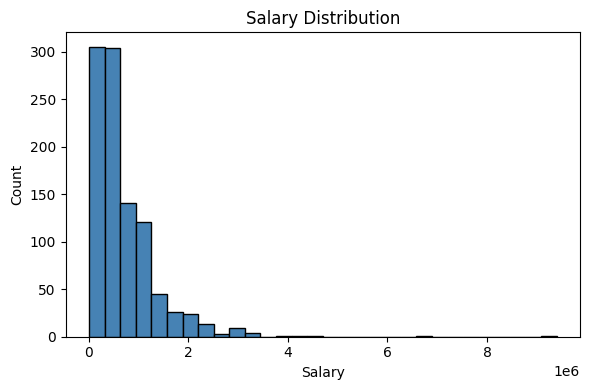

In [ ]:
# Plot salary distribution
plt.figure(figsize=(6, 4))
plt.hist(df['Salary'], bins=30, color='steelblue', edgecolor='black')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_eda_salary_distribution.png')
plt.show()


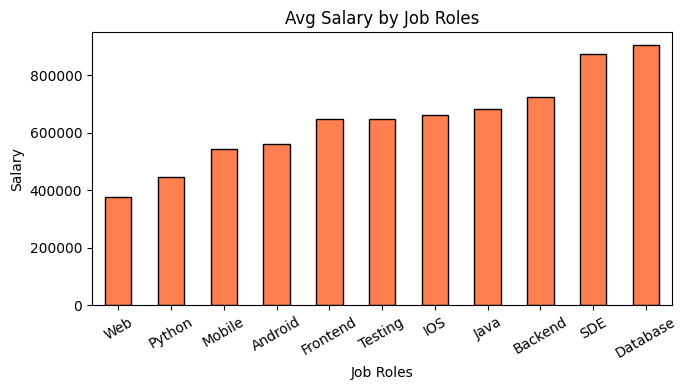

Step 3 Done: EDA Plots Saved


In [ ]:
import matplotlib.pyplot as plt

# Average salary by job roles (changed from education)
plt.figure(figsize=(7, 4))
df.groupby('Job Roles')['Salary'].mean().sort_values().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Avg Salary by Job Roles')
plt.ylabel('Salary')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot_eda_salary_by_job_roles.png')
plt.show()

print("Step 3 Done: EDA Plots Saved")

In [ ]:
# ── STEP 4: PREPROCESSING ────────────────────────────────────
# Drop missing values
df.dropna(inplace=True)

# Encode text columns to numbers
df_enc = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_enc.drop('Salary', axis=1)
y = df_enc['Salary']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nPreprocessing Complete")
print("Train size:", len(X_train), "| Test size:", len(X_test))


Preprocessing Complete
Train size: 800 | Test size: 200


In [ ]:
models = {
    'Linear Regression': LinearRegression(),

    'Ridge (L2)': Ridge(alpha=1.0),

    'Lasso (L1)': Lasso(alpha=0.05, max_iter=2000),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=8,
        min_samples_split=10,
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,              # 🔥 use all CPU cores
        random_state=42
    ),

    'Fast Boosting': HistGradientBoostingRegressor(
        max_iter=50,
        max_depth=8,
        random_state=42
    )
}

print("\nStep 5 Done:", len(models), "optimized models defined")


Step 5 Done: 6 optimized models defined


In [ ]:
import time

print("\nStep 6: Training and Evaluating Models")
print(f"\n{'Model':<22} {'RMSE':>10}  {'R² Score':>10}  {'Time (s)':>10}")
print("-" * 57)

rmse_scores = {}
r2_scores   = {}

for name, model in models.items():
    print(f"\n⏳ Training {name}...")   # helps identify slow model

    start_time = time.time()

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)

    execution_time = time.time() - start_time

    rmse_scores[name] = rmse
    r2_scores[name]   = r2

    print(f"{name:<22} {rmse:>10,.0f}  {r2:>10.4f}  {execution_time:>10.2f}")

print("\n✅ Step 6 Done: All Models Evaluated")


Step 6: Training and Evaluating Models

Model                        RMSE    R² Score    Time (s)
---------------------------------------------------------

⏳ Training Linear Regression...
Linear Regression      11,399,619   -423.7204        1.42

⏳ Training Ridge (L2)...
Ridge (L2)              1,625,955     -7.6405        0.45

⏳ Training Lasso (L1)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.101e+12, tolerance: 4.108e+10
  model = cd_fast.enet_coordinate_descent(


Lasso (L1)              4,399,922    -62.2721        1.54

⏳ Training Decision Tree...
Decision Tree             524,243      0.1018        0.09

⏳ Training Random Forest...
Random Forest             541,086      0.0431        1.16

⏳ Training Fast Boosting...
Fast Boosting             520,908      0.1132        2.53

✅ Step 6 Done: All Models Evaluated


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for HistGradientBoostingRegressor
param_grid = {
    'max_iter': [50, 100, 200], # Number of boosting stages
    'max_depth': [3, 5, 8],    # Maximum depth of the individual trees
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage to prevent overfitting
}

# Initialize GridSearchCV
# We use the existing X_train, y_train for training and X_test, y_test for evaluation.
# n_jobs=-1 uses all available CPU cores for parallel processing.
print("\nStep 7.1: Performing GridSearchCV for HistGradientBoostingRegressor...")
grid_search = GridSearchCV(HistGradientBoostingRegressor(random_state=42),
                           param_grid,
                           cv=3,
                           scoring='r2',
                           n_jobs=-1,
                           verbose=1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best R² score found:", grid_search.best_score_)



Step 7.1: Performing GridSearchCV for HistGradientBoostingRegressor...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters found: {'learning_rate': 0.01, 'max_depth': 3, 'max_iter': 200}
Best R² score found: 0.01321623529519833


In [ ]:
# Evaluate the best model from GridSearchCV
best_hgb_model = grid_search.best_estimator_
best_hgb_pred = best_hgb_model.predict(X_test)

# Calculate RMSE and R² for the best model
rmse_hgb = np.sqrt(mean_squared_error(y_test, best_hgb_pred))
r2_hgb = r2_score(y_test, best_hgb_pred)

print(f"\nEvaluated Tuned HistGradientBoostingRegressor:")
print(f"  RMSE      : {rmse_hgb:,.0f}")
print(f"  R² Score  : {r2_hgb:.4f}")

# Update the models dictionary with the tuned model
models['Tuned HistGradientBoosting'] = best_hgb_model
rmse_scores['Tuned HistGradientBoosting'] = rmse_hgb
r2_scores['Tuned HistGradientBoosting'] = r2_hgb

print("\nUpdated model list and scores with tuned HistGradientBoostingRegressor.")



Evaluated Tuned HistGradientBoostingRegressor:
  RMSE      : 524,614
  R² Score  : 0.1005

Updated model list and scores with tuned HistGradientBoostingRegressor.


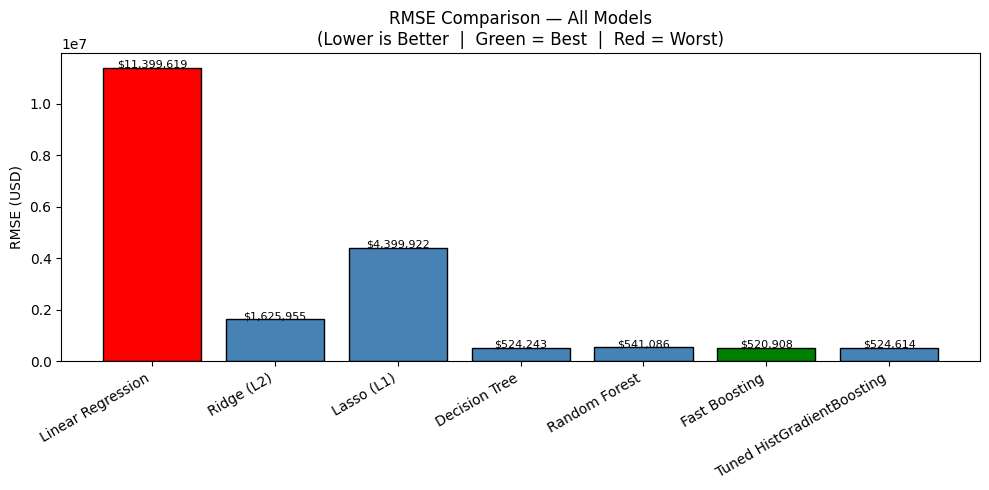

In [ ]:
# ── STEP 7: COMPARATIVE BAR CHARTS ───────────────────────────

# --- Bar Chart 1: RMSE Comparison ---
plt.figure(figsize=(10, 5))
colors = ['green' if v == min(rmse_scores.values()) else
          'red'   if v == max(rmse_scores.values()) else
          'steelblue' for v in rmse_scores.values()]
bars = plt.bar(rmse_scores.keys(), rmse_scores.values(), color=colors, edgecolor='black')
plt.title('RMSE Comparison — All Models\n(Lower is Better  |  Green = Best  |  Red = Worst)')
plt.ylabel('RMSE (USD)')
plt.xticks(rotation=30, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'${bar.get_height():,.0f}',
             ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_rmse_comparison.png')
plt.show()

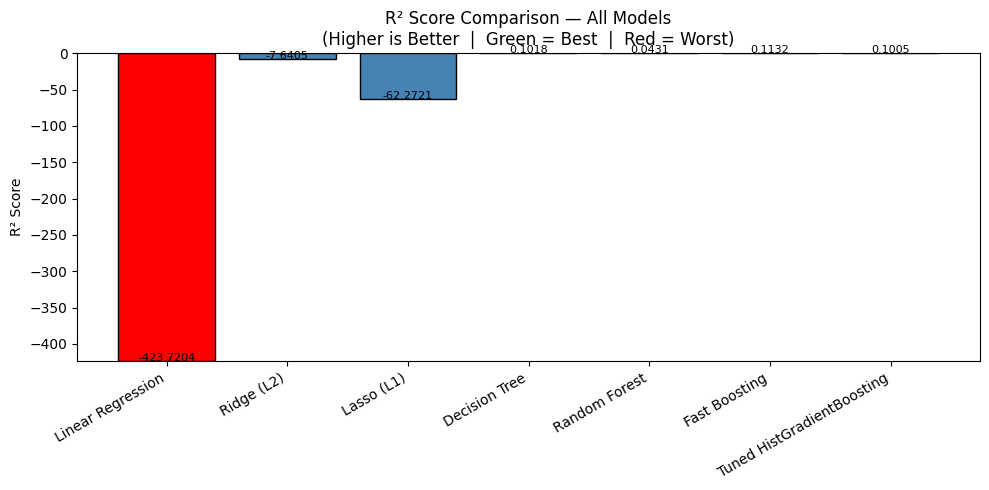

In [ ]:
# --- Bar Chart 2: R² Score Comparison ---
plt.figure(figsize=(10, 5))
colors2 = ['green' if v == max(r2_scores.values()) else
           'red'   if v == min(r2_scores.values()) else
           'steelblue' for v in r2_scores.values()]
bars2 = plt.bar(r2_scores.keys(), r2_scores.values(), color=colors2, edgecolor='black')
plt.title('R² Score Comparison — All Models\n(Higher is Better  |  Green = Best  |  Red = Worst)')
plt.ylabel('R² Score')
plt.xticks(rotation=30, ha='right')
# Dynamically adjust y-axis limits to show negative R² scores
min_r2 = min(r2_scores.values())
max_r2 = max(r2_scores.values())
plt.ylim(min_r2 - 0.1, max(0.1, max_r2 + 0.1))
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.4f}',
             ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot_r2_comparison.png')
plt.show()

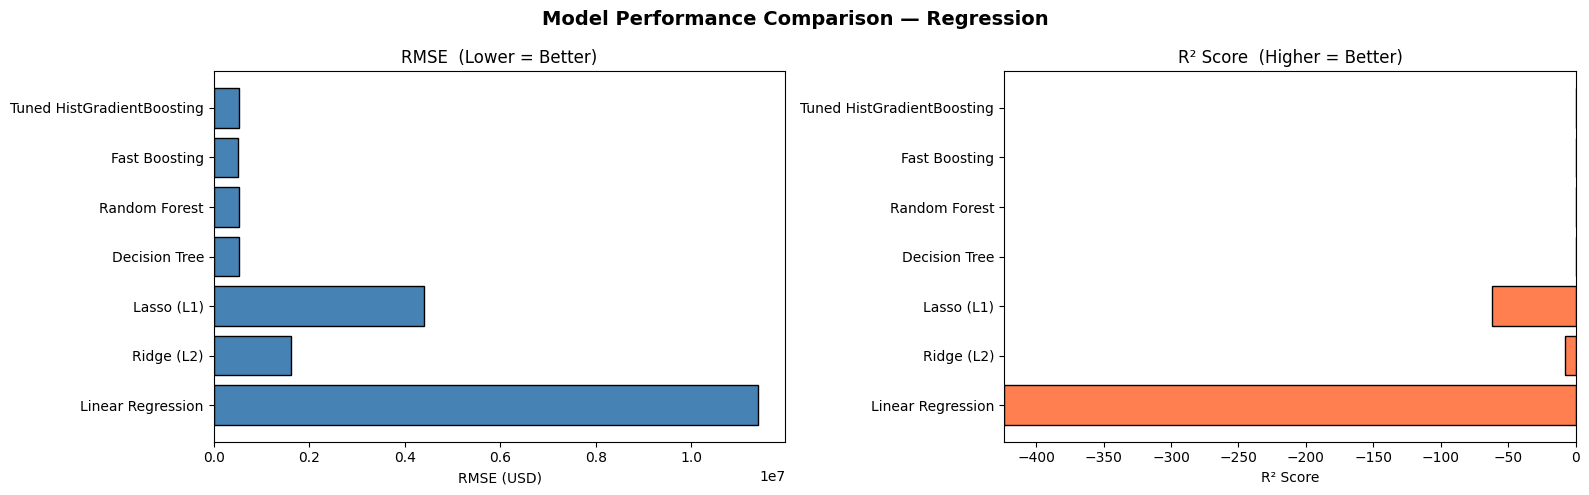

Step 7 Done: All comparison plots saved


In [ ]:
# --- Bar Chart 3: RMSE + R² side by side (grouped) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE
axes[0].barh(list(rmse_scores.keys()),
             list(rmse_scores.values()),
             color='steelblue', edgecolor='black')
axes[0].set_title('RMSE  (Lower = Better)')
axes[0].set_xlabel('RMSE (USD)')

# R²
axes[1].barh(list(r2_scores.keys()),
             list(r2_scores.values()),
             color='coral', edgecolor='black')
axes[1].set_title('R² Score  (Higher = Better)')
axes[1].set_xlabel('R² Score')

# Dynamically adjust x-axis limits for R² plot to show negative values
min_r2_val = min(r2_scores.values())
max_r2_val = max(r2_scores.values())
axes[1].set_xlim(min_r2_val - 0.1, max(0.1, max_r2_val + 0.1))

plt.suptitle('Model Performance Comparison — Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_side_by_side_comparison.png')
plt.show()

print("Step 7 Done: All comparison plots saved")

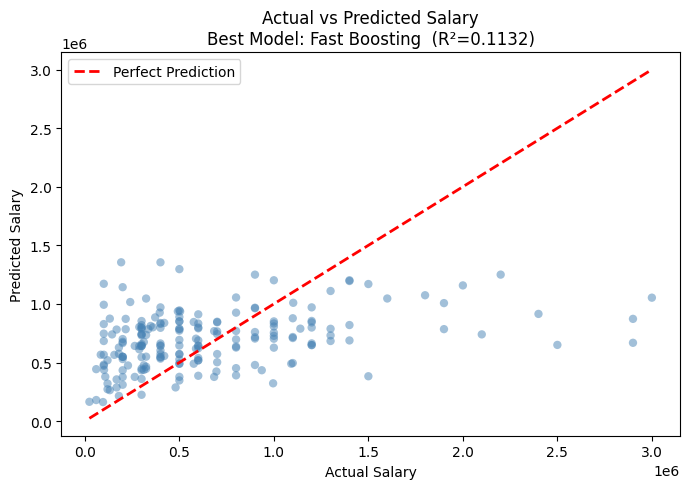

Step 8 Done: Actual vs Predicted plot saved


In [ ]:
# ── STEP 8: ACTUAL vs PREDICTED (Best Model) ─────────────────
best_model_name = max(r2_scores, key=r2_scores.get)
best_model      = models[best_model_name]
best_pred       = best_model.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_pred, alpha=0.5, color='steelblue', edgecolors='none')
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Salary\nBest Model: {best_model_name}  (R²={r2_scores[best_model_name]:.4f})')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png')
plt.show()

print("Step 8 Done: Actual vs Predicted plot saved")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.952e+12, tolerance: 4.108e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.963e+12, tolerance: 4.108e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.072e+12, tolerance: 4.108e

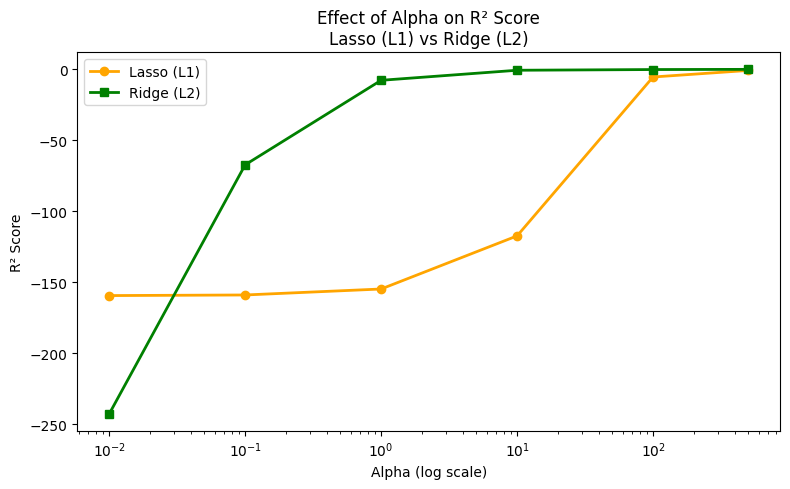

Step 9 Done: Lasso vs Ridge alpha plot saved


In [ ]:
# ── STEP 9: LASSO vs RIDGE — ALPHA EFFECT ────────────────────
alphas    = [0.01, 0.1, 1, 10, 100, 500]
lasso_r2  = []
ridge_r2  = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    r = Ridge(alpha=a).fit(X_train, y_train)
    lasso_r2.append(r2_score(y_test, l.predict(X_test)))
    ridge_r2.append(r2_score(y_test, r.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(alphas, lasso_r2, 'o-', label='Lasso (L1)', color='orange', linewidth=2)
plt.plot(alphas, ridge_r2, 's-', label='Ridge (L2)', color='green',  linewidth=2)
plt.xscale('log')
plt.title('Effect of Alpha on R² Score\nLasso (L1) vs Ridge (L2)')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R² Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot_lasso_vs_ridge_alpha.png')
plt.show()

print("Step 9 Done: Lasso vs Ridge alpha plot saved")


In [ ]:
# ── STEP 10: FINAL SUMMARY ───────────────────────────────────
print("\n" + "*" * 50)
print("  Our Final Model Results!")
print("  (Ranked by R² Score, higher is better!)")
print("" + "*" * 50)
print(f"{'Rank':<5} {'Model':<22} {'RMSE':>10}  {'R²':>8}")
print("-" * 50)

sorted_models = sorted(r2_scores.items(), key=lambda x: x[1], reverse=True)
for rank, (name, r2) in enumerate(sorted_models, 1):
    rmse = rmse_scores[name]
    tag  = ' (BEST!)'  if rank == 1          else \
           ' (WORST)' if rank == len(models) else ''
    print(f"{rank:<5} {name:<22} {rmse:>10,.0f}  {r2:>8.4f}{tag}")

best = sorted_models[0][0]
print(f"\n  Best Model is: {best} — Super excited about this one!")
print(f"  R² Score   : {r2_scores[best]:.4f}")
print(f"  RMSE Value : ${rmse_scores[best]:,.0f}")

print("\nAll our cool plots are saved as:")
for f in ['plot_eda_salary_distribution.png',
          'plot_eda_salary_by_education.png',
          'plot_rmse_comparison.png',
          'plot_r2_comparison.png',
          'plot_side_by_side_comparison.png',
          'plot_actual_vs_predicted.png',
          'plot_lasso_vs_ridge_alpha.png']:
    print(f"  • {f}")
print("\nThanks for checking out our project!")


**************************************************
  Our Final Model Results!
  (Ranked by R² Score, higher is better!)
**************************************************
Rank  Model                        RMSE        R²
--------------------------------------------------
1     Fast Boosting             520,908    0.1132 (BEST!)
2     Decision Tree             524,243    0.1018
3     Tuned HistGradientBoosting    524,614    0.1005
4     Random Forest             541,086    0.0431
5     Ridge (L2)              1,625,955   -7.6405
6     Lasso (L1)              4,399,922  -62.2721
7     Linear Regression      11,399,619  -423.7204 (WORST)

  Best Model is: Fast Boosting — Super excited about this one!
  R² Score   : 0.1132
  RMSE Value : $520,908

All our cool plots are saved as:
  • plot_eda_salary_distribution.png
  • plot_eda_salary_by_education.png
  • plot_rmse_comparison.png
  • plot_r2_comparison.png
  • plot_side_by_side_comparison.png
  • plot_actual_vs_predicted.png
  • plot_las

In [ ]:
import pickle

# Save the best performing model
pickle.dump(best_model, open('best_model.pkl', 'wb'))
print(f"Best model ('{best_model_name}') saved as 'best_model.pkl'")

Best model ('Fast Boosting') saved as 'best_model.pkl'
